# Użycie PySpark w celu eksploracji i wizualizacji danych (Wariant: Polska)

Zadanie polega na eksploracji i wizualizacji danych dotyczących pandemii COVID-19 w Polsce (`POL.csv`) z użyciem API Spark przez bibliotekę PySpark.

## 1. Konfigurowanie środowiska i sesja Spark
Konfigurujemy ścieżki środowiskowe `JAVA_HOME` oraz `HADOOP_HOME` (wymagane na systemie Windows) i tworzymy lokalną sesję Spark.

In [3]:
import os
import sys

# Konfiguracja środowiska Java i Hadoop dla systemu Windows
if 'JAVA_HOME' not in os.environ:
    os.environ['JAVA_HOME'] = r'C:\Program Files\KNIME\plugins\org.knime.binary.jre.win32.x86_64_17.0.5.20221116\jre'

os.environ['HADOOP_HOME'] = r'C:\Users\Patryk\antigravity\hadoop'
os.environ['PATH'] = os.path.join(os.environ['HADOOP_HOME'], 'bin') + os.pathsep + os.environ['PATH']

from pyspark.sql import SparkSession
from pyspark import SparkFiles

spark = SparkSession.builder \
        .master("local[*]") \
        .appName('PySpark_Lab1_POL') \
        .getOrCreate()

print(spark)

## 2. Pobieranie i czytanie danych
Pobieramy i odczytujemy dane z pliku CSV lokalnie (z folderu `data/POL.csv` lub `lab1/data/POL.csv`) oraz przy użyciu adresu URL (z użyciem biblioteki `urllib.request` w celu obejścia ograniczeń systemowych Windows).

In [4]:
import urllib.request
import tempfile

# Określenie poprawnej ścieżki do pliku lokalnego niezależnie od katalogu roboczego
notebook_dir = os.getcwd()
if os.path.basename(notebook_dir) == 'lab1':
    local_csv_file = 'data/POL.csv'
    output_dir = 'data'
else:
    local_csv_file = 'lab1/data/POL.csv'
    output_dir = 'lab1/data'

# 2.1. Czytanie pliku CSV lokalnie
df_local = spark.read.csv(local_csv_file, header=True, inferSchema=True)
print(f"Wczytano lokalny plik z {local_csv_file}. Liczba wierszy:", df_local.count())

# 2.2. Pobieranie danych za pomocą URL
url = 'https://storage.covid19datahub.io/country/POL.csv'
temp_dir = tempfile.gettempdir()
temp_file_path = os.path.join(temp_dir, "POL_temp.csv")

print(f"Pobieranie danych z URL: {url}...")
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response:
    with open(temp_file_path, 'wb') as out_file:
        out_file.write(response.read())

df_url = spark.read.csv(temp_file_path, header=True, inferSchema=True)
print("Wczytano plik z URL. Liczba wierszy:", df_url.count())

Wczytano lokalny plik z data/POL.csv. Liczba wierszy: 1408
Pobieranie danych z URL: https://storage.covid19datahub.io/country/POL.csv...
Wczytano plik z URL. Liczba wierszy: 1408


## 3. Strukturyzacja danych za pomocą schematu Spark
Wczytujemy dane i narzucamy jawne typowanie wybranych kolumn za pomocą rzutowania (cast).

In [5]:
from pyspark.sql.types import *
from pyspark.sql.functions import col

# Wybieramy kluczowe kolumny i jawnie rzutujemy ich typy
data = df_local.select(
    col('date').cast(DateType()).alias('date'),
    col('confirmed').cast(IntegerType()).alias('confirmed'),
    col('deaths').cast(IntegerType()).alias('deaths'),
    col('recovered').cast(IntegerType()).alias('recovered'),
    col('tests').cast(IntegerType()).alias('tests'),
    col('vaccines').cast(IntegerType()).alias('vaccines'),
    col('people_vaccinated').cast(IntegerType()).alias('people_vaccinated'),
    col('people_fully_vaccinated').cast(IntegerType()).alias('people_fully_vaccinated'),
    col('hosp').cast(IntegerType()).alias('hosp'),
    col('stringency_index').cast(DoubleType()).alias('stringency_index')
)

data.printSchema()

root
 |-- date: date (nullable = true)
 |-- confirmed: integer (nullable = true)
 |-- deaths: integer (nullable = true)
 |-- recovered: integer (nullable = true)
 |-- tests: integer (nullable = true)
 |-- vaccines: integer (nullable = true)
 |-- people_vaccinated: integer (nullable = true)
 |-- people_fully_vaccinated: integer (nullable = true)
 |-- hosp: integer (nullable = true)
 |-- stringency_index: double (nullable = true)



## 4. Metody kontroli danych
Sprawdzamy typy danych, liczbę wierszy, pierwsze rekordy oraz podstawowe statystyki opisowe.

In [6]:
# Typy kolumn
print("Typy kolumn:", data.dtypes)

# Liczba rekordów
print("Całkowita liczba rekordów:", data.count())

# Podgląd pierwszych wierszy
data.show(5)

# Podstawowe statystyki dla wybranych kolumn
data.select(['confirmed', 'deaths', 'people_vaccinated', 'stringency_index']).describe().show()

Typy kolumn: [('date', 'date'), ('confirmed', 'int'), ('deaths', 'int'), ('recovered', 'int'), ('tests', 'int'), ('vaccines', 'int'), ('people_vaccinated', 'int'), ('people_fully_vaccinated', 'int'), ('hosp', 'int'), ('stringency_index', 'double')]
Całkowita liczba rekordów: 1408
+----------+---------+------+---------+-----+--------+-----------------+-----------------------+----+----------------+
|      date|confirmed|deaths|recovered|tests|vaccines|people_vaccinated|people_fully_vaccinated|hosp|stringency_index|
+----------+---------+------+---------+-----+--------+-----------------+-----------------------+----+----------------+
|2020-01-03|     NULL|  NULL|     NULL| NULL|    NULL|             NULL|                   NULL|NULL|             0.0|
|2020-01-04|     NULL|  NULL|     NULL| NULL|    NULL|             NULL|                   NULL|NULL|             0.0|
|2020-01-05|     NULL|  NULL|     NULL| NULL|    NULL|             NULL|                   NULL|NULL|             0.0|
|2020

## 5. Radzenie sobie z brakującymi wartościami
Filtrujemy wiersze bez kluczowych skumulowanych danych (np. `confirmed` i `deaths`), ponieważ raportowanie w Polsce zostało przerwane w kwietniu 2023, a zastąpienie braków zerami zniekształciłoby wykresy skumulowane. Dla kolumn szczepień stosujemy uzupełnienie zerami (w początkowej fazie szczepionki były niedostępne).

In [7]:
from pyspark.sql import functions as f

# Filtrowanie wierszy z uzupełnionym raportowaniem zakażeń i zgonów
cleaned_data = data.filter(data.date.isNotNull() & data.confirmed.isNotNull() & data.deaths.isNotNull())

# Wypełnienie brakujących danych dla pozostałych kolumn numerycznych
cleaned_data = cleaned_data.na.fill({
    'recovered': 0,
    'tests': 0,
    'vaccines': 0,
    'people_vaccinated': 0,
    'people_fully_vaccinated': 0,
    'hosp': 0,
    'stringency_index': 0.0
})

print("Liczba wierszy po oczyszczeniu danych:", cleaned_data.count())

Liczba wierszy po oczyszczeniu danych: 1093


## 6. Zapytania, filtrowanie i agregacje danych
Filtrujemy dane oraz wyliczamy miesięczne agregacje (maksymalne i średnie wartości).

In [8]:
# 6.1. Wybór kolumn (Select)
cleaned_data.select('date', 'confirmed', 'deaths').show(5)

# 6.2. Filtrowanie (Filter) - okres od 2021 roku
filtered_data = cleaned_data.filter((col('date') >= '2021-01-01') & (col('confirmed') > 100000))
print("Liczba wierszy po przefiltrowaniu:", filtered_data.count())

# 6.3. GroupBy i Agregacja (grupowanie miesięczne)
agg_data = cleaned_data.withColumn('year_month', f.date_format('date', 'yyyy-MM'))

monthly_stats = agg_data.groupBy('year_month') \
    .agg(
        f.max('confirmed').alias('max_confirmed'),
        f.max('deaths').alias('max_deaths'),
        f.max('people_vaccinated').alias('max_vaccinated'),
        f.avg('stringency_index').alias('avg_stringency')
    ) \
    .orderBy('year_month')

monthly_stats.show(15)

+----------+---------+------+
|      date|confirmed|deaths|
+----------+---------+------+
|2020-03-12|       49|     1|
|2020-03-13|       68|     2|
|2020-03-14|      103|     3|
|2020-03-15|      119|     3|
|2020-03-16|      177|     4|
+----------+---------+------+
only showing top 5 rows
Liczba wierszy po przefiltrowaniu: 798
+----------+-------------+----------+--------------+------------------+
|year_month|max_confirmed|max_deaths|max_vaccinated|    avg_stringency|
+----------+-------------+----------+--------------+------------------+
|   2020-03|         2311|        33|             0| 56.62249999999998|
|   2020-04|        12877|       644|             0| 84.19699999999996|
|   2020-05|        23786|      1064|             0| 81.53838709677419|
|   2020-06|        34393|      1463|             0| 57.77766666666668|
|   2020-07|        45688|      1716|             0| 42.67967741935481|
|   2020-08|        67372|      2039|             0| 39.80999999999997|
|   2020-09|       

## 7. Wizualizacja danych
Konwertujemy wyniki Spark DataFrame do Pandas DataFrame w celu wygenerowania wykresów za pomocą biblioteki `matplotlib`.

C:\Users\Patryk\AppData\Local\Temp\ipykernel_14064\3802453909.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(pd_df['year_month'], rotation=45, ha='right')


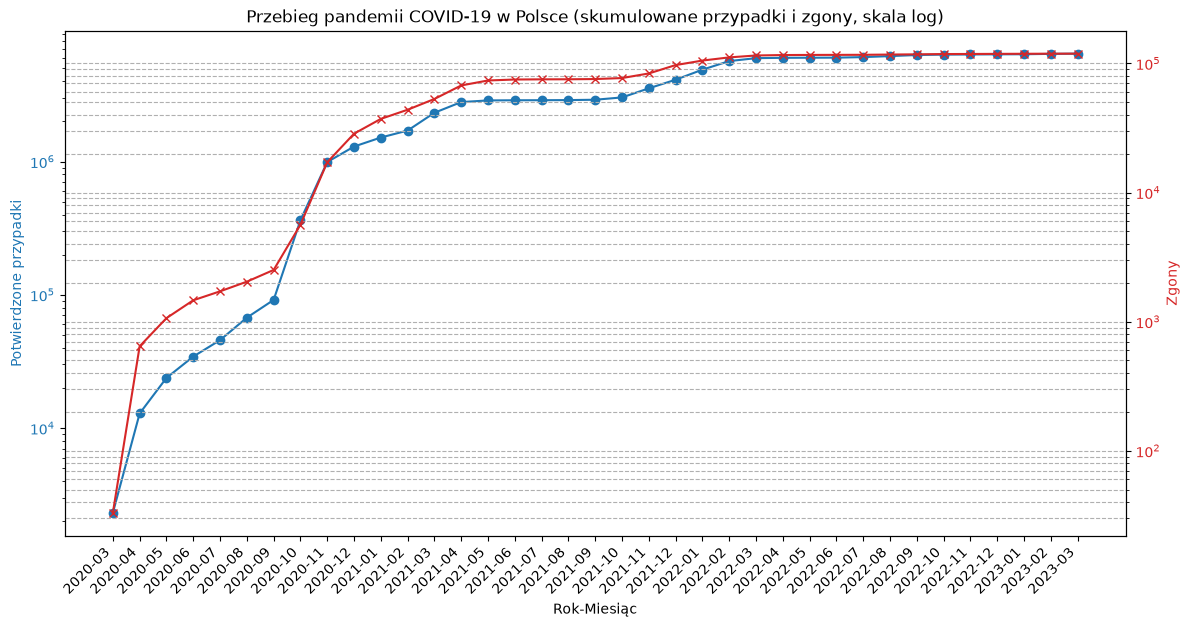

C:\Users\Patryk\AppData\Local\Temp\ipykernel_14064\3802453909.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(pd_df['year_month'], rotation=45, ha='right')


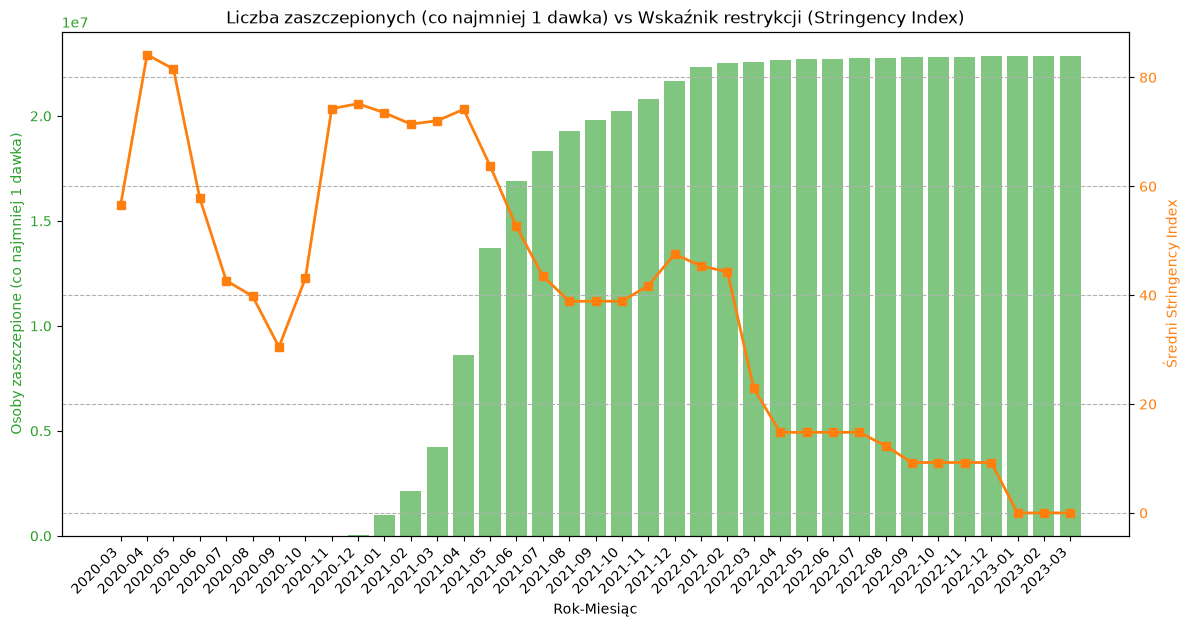

In [9]:
import matplotlib.pyplot as plt

pd_df = monthly_stats.toPandas()
pd_df = pd_df.sort_values('year_month')

# Wykres 1: Skumulowana liczba zakażeń i zgonów (skala logarytmiczna)
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Rok-Miesiąc')
ax1.set_ylabel('Potwierdzone przypadki', color=color)
ax1.plot(pd_df['year_month'], pd_df['max_confirmed'], color=color, marker='o', label='Potwierdzone')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Zgony', color=color)
ax2.plot(pd_df['year_month'], pd_df['max_deaths'], color=color, marker='x', label='Zgony')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

plt.title('Przebieg pandemii COVID-19 w Polsce (skumulowane przypadki i zgony, skala log)')
fig.tight_layout()
ax1.set_xticklabels(pd_df['year_month'], rotation=45, ha='right')
plt.grid(True, which="both", ls="--")
plt.show()

# Wykres 2: Liczba zaszczepionych a wskaźnik restrykcji rządowych (Stringency Index)
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:green'
ax1.set_xlabel('Rok-Miesiąc')
ax1.set_ylabel('Osoby zaszczepione (co najmniej 1 dawka)', color=color)
ax1.bar(pd_df['year_month'], pd_df['max_vaccinated'], color=color, alpha=0.6, label='Zaszczepieni')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Średni Stringency Index', color=color)
ax2.plot(pd_df['year_month'], pd_df['avg_stringency'], color=color, marker='s', linewidth=2, label='Stringency Index')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Liczba zaszczepionych (co najmniej 1 dawka) vs Wskaźnik restrykcji (Stringency Index)')
fig.tight_layout()
ax1.set_xticklabels(pd_df['year_month'], rotation=45, ha='right')
plt.grid(True, ls="--")
plt.show()

## 8. Zapisywanie danych do pliku
Zapisujemy zagregowane statystyki do formatów CSV, JSON i Parquet, a następnie zamykamy sesję Spark.

In [10]:
import shutil

csv_out = os.path.join(output_dir, 'monthly_stats_pol.csv')
json_out = os.path.join(output_dir, 'monthly_stats_pol.json')
parquet_out = os.path.join(output_dir, 'monthly_stats_pol.parquet')

# Czyszczenie starych plików w celu uniknięcia błędów zapisu na Windows
for p in [csv_out, json_out, parquet_out]:
    if os.path.exists(p):
        shutil.rmtree(p, ignore_errors=True)

# 8.1. Zapis do CSV
monthly_stats.write.csv(csv_out, header=True)
print("Zapisano dane do:", csv_out)

# 8.2. Zapis do JSON
monthly_stats.write.save(json_out, format='json')
print("Zapisano dane do:", json_out)

# 8.3. Zapis do Parquet
monthly_stats.write.save(parquet_out, format='parquet')
print("Zapisano dane do:", parquet_out)

# Zatrzymanie sesji
spark.stop()
print("Sesja Spark została pomyślnie zamknięta.")

Zapisano dane do: data\monthly_stats_pol.csv
Zapisano dane do: data\monthly_stats_pol.json
Zapisano dane do: data\monthly_stats_pol.parquet
Sesja Spark została pomyślnie zamknięta.
